# Image Classification and Denoising
This notebook classifies images as photos or non-photos, adds noise to detected photos, and denoises them using pre-trained models.

In [56]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img
from tensorflow.keras import layers, models
import imageio

# ------------------------------------
# Config
# ------------------------------------
DATASET_DIR = "./dataset"
CLASSIFIER_PATH = "multitask_photo_model.keras"
DENOISER_PATH = "liv2-denoising.h5"

# image size for each model
CLASSIFIER_SIZE = (224, 224)
DENOISER_SIZE = (224, 224)
CLASS_NAMES = ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']


In [57]:
# Load models
classifier = load_model(CLASSIFIER_PATH)

def build_denoiser(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    c1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2,2), padding='same')(c1)
    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2,2), padding='same')(c2)
    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p2)
    u1 = layers.UpSampling2D((2,2))(c3)
    concat1 = layers.Concatenate()([u1, c2])
    c4 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(concat1)
    u2 = layers.UpSampling2D((2,2))(c4)
    concat2 = layers.Concatenate()([u2, c1])
    c5 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(concat2)
    outputs = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(c5)
    model = models.Model(inputs, outputs)
    return model

denoiser = build_denoiser()
denoiser.load_weights(DENOISER_PATH)

In [58]:
def load_images(folder, target_size=(224, 224)):  # changer de 128 à 224
    images = []
    paths = []
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        if not os.path.isfile(path):
            continue
        try:
            img = load_img(path, target_size=target_size)
            arr = img_to_array(img) / 255.0
            images.append(arr)
            paths.append(path)
        except Exception as e:
            print(f'Skipped {fname}: {e}')
    return np.array(images), paths

X, paths = load_images(DATASET_DIR, target_size=(224,224))
print(f'Loaded {len(X)} images from {DATASET_DIR}.')

Loaded 200 images from ./dataset.


In [59]:
# Classify and filter photos only
preds = classifier.predict(X)

# Vérifier le type et les formes des sorties
if isinstance(preds, list):
    for i, p in enumerate(preds):
        print(f"Output {i}: shape={p.shape}")

# Supposons que la sortie que tu veux est preds[0] si liste
class_preds = preds[0] if isinstance(preds, list) else preds

# Si class_preds a une seule colonne, utiliser directement > 0.5
photo_mask = (class_preds.flatten() > 0.5)

# Filtrer les images et chemins
X_photos = X[photo_mask]
photo_paths = [p for i, p in enumerate(paths) if photo_mask[i]]

print(f'Detected {len(X_photos)} photos out of {len(X)} total images.')

# Afficher les chemins des photos détectées
for i, path in enumerate(photo_paths, 1):
    print(f'{i} - Photo: {path}')
    detected_dir = "./detected_photos"
    os.makedirs(detected_dir, exist_ok=True)
    img_uint8 = (X_photos[i-1] * 255).astype(np.uint8)
    imageio.imsave(os.path.join(detected_dir, os.path.basename(path)), img_uint8)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step
Output 0: shape=(200, 1)
Output 1: shape=(200, 5)
Detected 110 photos out of 200 total images.
1 - Photo: ./dataset/photo_0011.jpg
2 - Photo: ./dataset/painting_00046.jpg
3 - Photo: ./dataset/photo_0002.jpg
4 - Photo: ./dataset/painting_00032.jpg
5 - Photo: ./dataset/photo_0071.jpg
6 - Photo: ./dataset/photo_0047.jpg
7 - Photo: ./dataset/photo_0093.jpg
8 - Photo: ./dataset/painting_00023.jpg
9 - Photo: ./dataset/painting_00011.jpg
10 - Photo: ./dataset/painting_00044.jpg
11 - Photo: ./dataset/painting_00009.jpg
12 - Photo: ./dataset/photo_0074.jpg
13 - Photo: ./dataset/photo_0060.jpg
14 - Photo: ./dataset/photo_0092.jpg
15 - Photo: ./dataset/photo_0057.jpg
16 - Photo: ./dataset/photo_0005.jpg
17 - Photo: ./dataset/photo_0039.jpg
18 - Photo: ./dataset/painting_00048.jpg
19 - Photo: ./dataset/photo_0076.jpg
20 - Photo: ./dataset/painting_00022.jpg
21 - Photo: ./dataset/photo_0062.jpg
22 - Photo: ./dataset/painting_00003.jpg
23 - Photo: ./dataset/sch

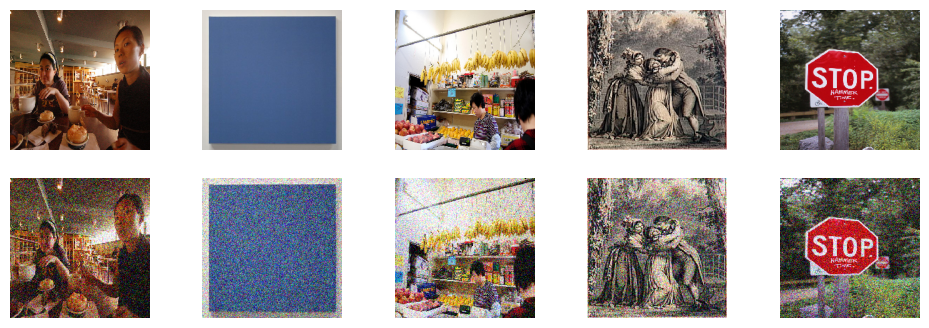

In [60]:
# Add noise only to detected photos
def add_noise(images, noise_factor=0.2):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = np.clip(noisy, 0., 1.)
    return noisy

X_noisy = add_noise(X_photos)

# Show a few examples
n = min(5, len(X_noisy))
plt.figure(figsize=(12, 4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(X_photos[i])
    plt.axis('off')
    plt.subplot(2, n, i+1+n)
    plt.imshow(X_noisy[i])
    plt.axis('off')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


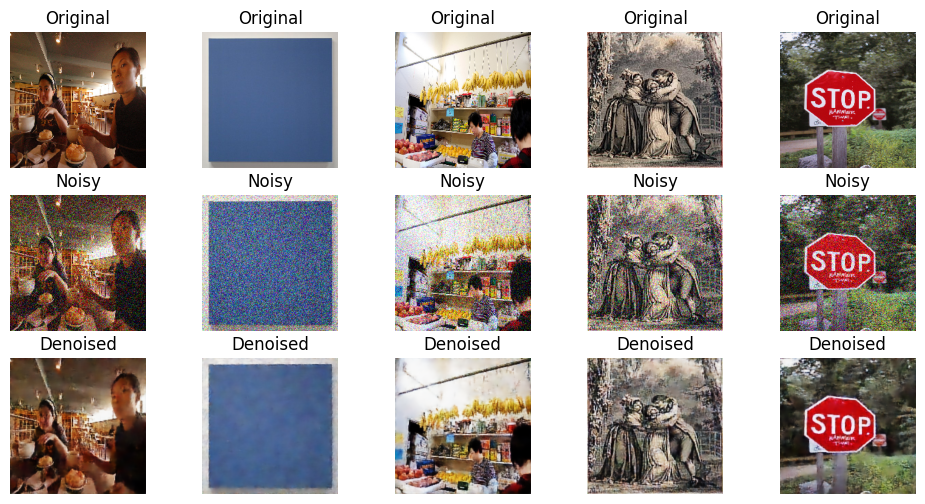

In [61]:
# Denoise only the photo images
X_denoised = denoiser.predict(X_noisy)

# Show original, noisy, and denoised
n = min(5, len(X_denoised))
plt.figure(figsize=(12, 6))
for i in range(n):
    plt.subplot(3, n, i+1)
    plt.imshow(X_photos[i])
    plt.axis('off')
    plt.title('Original')

    plt.subplot(3, n, i+1+n)
    plt.imshow(X_noisy[i])
    plt.axis('off')
    plt.title('Noisy')

    plt.subplot(3, n, i+1+2*n)
    plt.imshow(X_denoised[i])
    plt.axis('off')
    plt.title('Denoised')
plt.show()

In [63]:
# Save only denoised photos
OUTPUT_DIR = './denoised_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for img_arr, path in zip(X_denoised, photo_paths):
    name = os.path.basename(path)
    out_path = os.path.join(OUTPUT_DIR, name)
    array_to_img(img_arr).save(out_path)

print('Denoised photo images saved in', OUTPUT_DIR)

Denoised photo images saved in ./denoised_results
